# Combined Reversal/Momentum Strategy
This project first identifies a correlated basket in the cryptocurrency market, with the target cryptocurrency being Bitcoin. During the process of refining the reversal strategy, a momentum strategy was uncovered, which accounts for the bullish markets that started to emerge in 2024. The strategies have been combined to account for the different trends that occur when bearish, bullish, or mean-reverting markets dominate.

## Reversal Strategy

The code below obtains Binance data on 23 cryptos; they are as follows: Bitcoin, Ethereum, Ripple, Solana, Binance Coin, Polkadot, Chainlink, Litecoin, Uniswap, Aave, Cardano, Avalanche, Dogecoin, Ethereum Classic, NEAR Protocol, Stellar, Bitcoin Cash, Sui, Artificial Superintelligence Alliance, Internet Computer, Render, Floki, and Shiba Inu. The correlated basket is comprised of all crypto assets excluding Bitcoin. The test data are the tickers' prices and returns from January 2024 to January 2025; the training data are the prices and returns from January 2019 to the end of 2023.

In [1]:
from binance.client import Client as bnb_client
from datetime import datetime
import pandas as pd 
import numpy as np 
from sklearn.linear_model import LinearRegression

client = bnb_client(tld='US')


def get_binance_px(symbol,freq,start_ts = '2019-01-01', end_ts = '2025-01-01'):
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
    data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
    return data 

univ = ['BTCUSDT','ETHUSDT','XRPUSDT','SOLUSDT','BNBUSDT','DOTUSDT',
        'LINKUSDT','LTCUSDT','UNIUSDT','AAVEUSDT','ADAUSDT','AVAXUSDT','DOGEUSDT',
       'ETCUSDT','NEARUSDT','XLMUSDT','BCHUSDT','SUIUSDT','FETUSDT',
       'ICPUSDT','RNDRUSDT','FLOKIUSDT','SHIBUSDT'] 

freq = '4h'
px = {}
for x in univ:
    data = get_binance_px(x,freq)
    px[x] = data.set_index('open_time')['close']

px = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
ret = px.pct_change()

In [2]:
train_end = '2023-12-31'
test_start = '2024-01-01'

Each of the assets' correlation score with Bitcoin is shown below. The correlation coefficients show considerable variation, with values ranging from 0.097 to 0.96.

In [3]:
btc_corr = {}
btc_ret = ret['BTCUSDT']
basket_ret = ret.drop(columns = ['BTCUSDT'])

for x in basket_ret.columns:
    btc_corr[x] = px.corr().at['BTCUSDT', x]
    
btc_corr = pd.DataFrame(btc_corr, index = {'Correlation with BTC'}).T
btc_corr

,Correlation with BTC
ETHUSDT,0.870127
XRPUSDT,0.738085
SOLUSDT,0.836047
BNBUSDT,0.889342
DOTUSDT,0.097359
LINKUSDT,0.790759
LTCUSDT,0.476255
UNIUSDT,0.417932
AAVEUSDT,0.502878
ADAUSDT,0.527214


The following code uses a linear regression to determine the optimal weights of the assets within the correlated basket.

In [4]:
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm

X = basket_ret.fillna(0)
Y = btc_ret.fillna(0)

model = RollingOLS(Y, X, window = 25, min_nobs = 22)
result = model.fit()

ideal_weights = pd.DataFrame(
    result.params.values,
    index = btc_ret.index,
    columns = basket_ret.columns
)

ideal_weights = ideal_weights.div(ideal_weights.abs().sum(axis=1), axis = 0)

The following code segments transform the return differential of the basket vs. Bitcoin into a signal that determines whether to short/long either asset or exit a position. The signal is determined by transforming raw return data via the z-score and then the tanh filter function. Transaction costs are a factor when deciding whether to enter a position: expected profit must overcome the money lost to transaction costs.

In [5]:
basket_ret_sum = (ideal_weights.shift() * basket_ret).sum(axis = 1)
basket_cum_ret = (1 + basket_ret_sum).cumprod()
btc_cum_ret = (1 + btc_ret).cumprod()

spread = btc_cum_ret - basket_cum_ret

In [6]:
z_window = 20
z_mean = spread.shift(1).rolling(z_window, min_periods = 1).mean()
z_std = spread.shift(1).rolling(z_window, min_periods = 1).std()
z_score = (spread - z_mean) / z_std
z_score = -np.tanh(z_score)

In [7]:
t_cost = 20 * 1e-4
round_trip_cost = 2 * t_cost
expected_profit = z_score * z_std

entry = 0.65
exit = 0.3

reversal_weights = pd.Series(0, index = z_score.index)
reversal_weights[(z_score > entry) & (expected_profit > round_trip_cost)] = -1   # short target / long basket
reversal_weights[(z_score < -entry) & (expected_profit < -round_trip_cost)] = 1   # long target / short basket
reversal_weights[z_score.abs() < exit] = 0  
reversal_weights = reversal_weights.ffill()  # hold position until exit

In [8]:
temp = reversal_weights.shift() * btc_ret - reversal_weights.shift() * basket_ret_sum
temp = temp.loc[test_start:]

reversal_stats = {}
reversal_stats['avg_ret'] = temp.mean() * 365 * 6
reversal_stats['vol'] = temp.std() * np.sqrt(365 * 6)
reversal_stats['sharpe'] = temp.mean() / temp.std() * np.sqrt(365 * 6)
reversal_stats = pd.Series(reversal_stats)

print("Sharpe ratio of reversal strategy: ", reversal_stats['sharpe'])

Sharpe ratio of reversal strategy:  1.5471424281728636


## Momentum Strategy

The following code segments construct the optimal weights of a momentum strategy on the same six crypto assets. The approximate weights are first calculated by simply ranking the assets' returns, demeaning the ranks, and normalizing them. The Ledoit-Wolf shrinkage estimator was used to optimize these weights to reduce tracking error and fulfill the constraints of a fully invested and long-only portfolio.

In [9]:
avg_ret = ret.rolling(15, min_periods=1).mean().rank(1)
avg_ret = avg_ret.subtract(avg_ret.mean(1),0)
momentum_weights = avg_ret.divide(avg_ret.abs().sum(1),0)

In [10]:
import warnings
import cvxpy as cvx
from sklearn.covariance import LedoitWolf

warnings.filterwarnings("ignore", category=UserWarning, module="cvxpy")
w = cvx.Variable(ret.shape[1])

def get_tracking_error(w, ideal, sigma):    
    param = cvx.Parameter(shape = sigma.shape, value = sigma, PSD = True)
    tracking_error = cvx.quad_form(w, param) - 2 * ideal @ sigma @ w  - ideal @ sigma @ ideal
    return tracking_error
    
opt_momentum_weights = pd.DataFrame([], columns = momentum_weights.columns)

tcost_bps = 20
constraints = []
fully_invested = cvx.sum(w) == 1
long_only = w >= 0
max_weights = w <= 0.15

constraints.append(fully_invested)
constraints.append(long_only)
constraints.append(max_weights)

for x in momentum_weights.index:
    sigma = ret.iloc[0:momentum_weights.index.get_loc(x) + 1].cov()
    sigma_lw = LedoitWolf().fit(ret.iloc[0:momentum_weights.index.get_loc(x) + 1].fillna(0).values).covariance_
    
    w_prev = momentum_weights.iloc[momentum_weights.index.get_loc(x)-1].fillna(0)
    turnover = cvx.norm1(w - w_prev)
    
    temp = momentum_weights.loc[x].fillna(0)
    tracking_error = get_tracking_error(w, temp, sigma_lw)
    objective = cvx.Minimize(tracking_error + tcost_bps * 1e-4 * turnover)
    prob = cvx.Problem(objective, constraints)
    prob.solve()
    opt_momentum_weights.loc[x] = pd.Series(w.value, index = temp.index)

/Users/25ainsliec/opt/anaconda3/lib/python3.9/site-packages/sklearn/covariance/_shrunk_covariance.py:229: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/Users/25ainsliec/opt/anaconda3/lib/python3.9/site-packages/sklearn/covariance/_empirical_covariance.py:86: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(


In [11]:
temp = opt_momentum_weights.shift() * ret
temp = temp.sum(axis = 1).loc[test_start:]

momentum_stats = {}
momentum_stats['avg_ret'] = temp.mean() * 365 * 6
momentum_stats['vol'] = temp.std() * np.sqrt(365 * 6)
momentum_stats['sharpe'] = temp.mean() / temp.std() * np.sqrt(365 * 6)
momentum_stats = pd.Series(momentum_stats)

print("Sharpe ratio of momentum strategy: ", momentum_stats['sharpe'])

Sharpe ratio of momentum strategy:  2.2721705321399583


## Combining Reversal and Momentum

The following code optimally combines the reversal and momentum strategies by accounting for the covariance matrix of their historical returns. The results of the combined strategy are shown below, with the combined Sharpe ratio outperforming the Sharpes of the two strategies separately. 

In [12]:
stats = pd.concat([reversal_stats, momentum_stats], axis = 1)
stats.columns = ['reversal', 'momentum']
stats

,reversal,momentum
avg_ret,0.596376,1.813773
vol,0.385470,0.798256
sharpe,1.547142,2.272171


In [13]:
reversal_ret = reversal_weights.shift() * btc_ret - reversal_weights.shift() * basket_ret_sum
momentum_ret = opt_momentum_weights.shift() * ret
momentum_ret = momentum_ret.sum(axis = 1)

all_rets = pd.concat([reversal_ret, momentum_ret], axis = 1)
all_rets.columns = ['reversal', 'momentum']

train_rets = all_rets.loc[:train_end]
test_rets = all_rets.loc[test_start:]

In [14]:
def optimal_weights(sigma,mu):   
    wgt = np.linalg.inv(sigma) @ mu
    wgt = wgt / np.abs(wgt).sum()
    return wgt

combo_rets = pd.DataFrame(np.nan, index = all_rets.index, columns = all_rets.columns, dtype = float)
window = 365 * 6

final_weights = {}

for i in range(window, len(all_rets)):
    idx  = all_rets.index[i]
    hist = all_rets.iloc[i - window:i].fillna(0)
    
    if idx > pd.Timestamp(train_end):
        hist = all_rets.loc[:train_end].fillna(0)
    
    sigma_i     = LedoitWolf().fit(hist.values).covariance_
    mu_i        = hist.mean().values
    weights_opt = optimal_weights(sigma_i, mu_i)
    final_weights[idx] = weights_opt
    combo_rets.loc[idx] = all_rets.loc[idx].values * weights_opt
    
combo_rets = combo_rets.sum(axis = 1)

final_weights = pd.DataFrame(final_weights).T
temp_btc_weights = pd.DataFrame(reversal_weights, columns = ['BTCUSDT'])
temp_basket_weights = -1 * ideal_weights.mul(reversal_weights, axis = 'index')
temp_rev_weights = pd.concat([temp_btc_weights, temp_basket_weights],axis = 1)
final_weights = temp_rev_weights.mul(final_weights[0], axis = 'index') + opt_momentum_weights.mul(final_weights[1],axis = 'index')
final_turnover = (final_weights.fillna(0) - final_weights.shift().fillna(0)).abs().sum(1)

def get_stats(rets, turnover):
    stats = {}
    stats['avg ret'] = rets.mean()
    stats['vol'] = rets.std() * np.sqrt(365 * 6)
    stats['sharpe'] = rets.mean() / rets.std() * np.sqrt(365 * 6)
    stats['cost-adjusted sharpe'] = (rets - turnover * 1e-4 * tcost_bps).mean() / (rets - turnover * 1e-4 * tcost_bps).std() * np.sqrt(365 * 6)
    stats = pd.DataFrame([stats], index = ['combined strategies'])
    return stats

get_stats(combo_rets.loc[test_start:],final_turnover[test_start:])


,avg ret,vol,sharpe,cost-adjusted sharpe
combined strategies,0.000712,0.630659,2.473981,0.45529


The combined Sharpe ratio of 2.47 is very promising. The cost-adjusted Sharpe of 0.45 reflects the estimated returns after deducting transaction costs. More relevant metrics are detailed below, including max drawdowns, alpha values, and beta values.

## Related Results

These are the max drawdowns of the underlying crypto assets. The numbers show considerable downside risk.

In [15]:
def drawdown(px):
    return (px / px.expanding(min_periods=1).max() - 1)

dd = drawdown(px)

max_dd = pd.DataFrame([dd.min().values],columns = dd.min().index,index = ['max drawdowns']).T
max_dd

,max drawdowns
BTCUSDT,-0.770353
ETHUSDT,-0.811619
XRPUSDT,-0.755826
SOLUSDT,-0.966031
BNBUSDT,-0.724769
DOTUSDT,-0.900876
LINKUSDT,-0.808914
LTCUSDT,-0.896868
UNIUSDT,-0.922425
AAVEUSDT,-0.893767


Additional stats are shown below. The max drawdown of the combined strategy was computed by assuming a starting portfolio value of $1.

<AxesSubplot:>

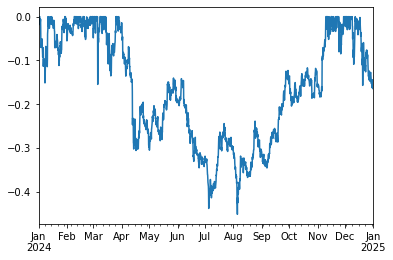

In [16]:
mean_turnover = final_turnover[test_start:].mean()

annual_vol = combo_rets[test_start:].std() * np.sqrt(365 * 6)

percent_change = combo_rets + 1
cur_val = 1
pnl = pd.Series(dtype = float)
start_time =  combo_rets[test_start:].index[0]
for x in range(combo_rets.index.get_loc(start_time), len(combo_rets)):
    pnl[combo_rets.index[x]] = cur_val * percent_change[x]
    cur_val *= percent_change[x]

strat_dd = pnl / pnl.expanding(min_periods=1).max() - 1
max_strat_dd = strat_dd.min()

addl_stats = {}
addl_stats['mean turnover'] = mean_turnover
addl_stats['annualized volatility'] = annual_vol
addl_stats['strategy max drawdown'] = max_strat_dd
addl_stats = pd.DataFrame([addl_stats],index = ['additional stats'])
addl_stats

strat_dd.plot()

A linear regression was run on the combined portfolio, with Bitcoin returns representing market returns. Alpha values are positive, and beta values are on the order of 10^-4, which demonstrates that the portfolio remains market neutral. However, the alpha t-stat of 1.70 is below the 2.0 threshold for statistical significance, suggesting that there is a possibility the alpha is due to noise in the market. The information ratio of 1.70, on the other hand, suggests consistent excess returns relative to Bitcoin. Even if the alpha signal is moderate, the portfolio is consistently generating profit.

In [17]:
X = btc_ret[test_start:]
X = sm.add_constant(X)
Y = combo_rets[test_start:]

In [18]:
X = X.fillna(0)
Y = Y.fillna(0)
results = sm.OLS(Y, X).fit()

In [19]:
regression = results.params['BTCUSDT']*X['BTCUSDT'] + results.params['const'] + results.resid
beta_contr = results.params['BTCUSDT']*X['BTCUSDT']
prediction = results.params['BTCUSDT']*X['BTCUSDT'] + results.params['const']
alpha_contr = results.params['const'] + results.resid

alpha_beta = {}
alpha_beta['alpha'] = alpha_contr.mean()
alpha_beta['beta'] = results.params['BTCUSDT']
alpha_beta['alpha corr to BTC'] = alpha_contr.corr(X['BTCUSDT'])
alpha_beta['alpha t-stat'] = results.tvalues['const']
alpha_beta['information ratio'] = alpha_contr.mean()/alpha_contr.std()*np.sqrt(365 * 6)
alpha_beta = pd.DataFrame([alpha_beta], index = ['regression metrics'])

alpha_beta

,alpha,beta,alpha corr to BTC,alpha t-stat,information ratio
regression metrics,0.000324,0.918464,3.414219e-16,1.704182,1.703107


<AxesSubplot:>

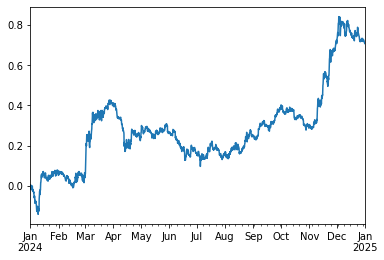

In [20]:
alpha_contr.cumsum().plot()

<AxesSubplot:>

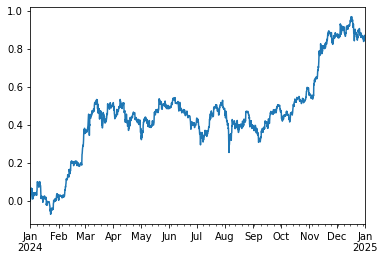

In [21]:
beta_contr.cumsum().plot()